##**A. Steam 데이터 로딩 및 전처리**

In [ ]:
#Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

#작업 디렉토리 설정
import os
drive_path = '/content/drive/MyDrive/RecSys/Data'
os.chdir(drive_path)

#위치 확인
print("Contents of the directory:")
!pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of the directory:
/content/drive/MyDrive/RecSys/Data


###**데이터프레임 변환**

**steam_user_data_filtered.csv**: **사용자**가 플레이한 게임 및 플레이 시간 데이터

-> **users_df**로 변환

**steamspy_detailed_games.csv**: **게임** 정보(개발사, 유통사, 장르 태그 등) 데이터

-> **games_df**로 변환



In [ ]:
#필요한 라이브러리 import
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict


#재현성을 위한 random seed 고정
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
#.csv를 pandas dataframe으로 변환
user_data = pd.read_csv('steam_user_data_filtered.csv')
steam_data = pd.read_csv('steamspy_detailed_games.csv')

#dataframe 확인
display(user_data.head())
display(steam_data.head())

,steamid,game_name,appid,playtime_forever,achievements
0,'76561198828387620,Left 4 Dead 2,550,198.0,0.0
1,'76561198828387620,War Thunder,236390,0.0,0.0
2,'76561198828387620,theHunter Classic,253710,29.0,0.0
3,'76561198828387620,Card Hunter,293260,69.0,1.0
4,'76561198828387620,Star Trek Online,9900,9.0,0.0


,appid,name,developer,publisher,genre,owners,price,initialprice,languages,tags,score_rank,positive,negative
0,570,Dota 2,Valve,Valve,"Action, Strategy, Free To Play","200,000,000 .. 500,000,000",0.00,0.00,"English, Bulgarian, Czech, Danish, Dutch, Finn...","Free to Play(59993), MOBA(20198), Multiplayer(...",NaN,2014415,456637
1,730,Counter-Strike: Global Offensive,Valve,Valve,"Action, Free To Play","100,000,000 .. 200,000,000",0.00,0.00,"English, Czech, Danish, Dutch, Finnish, French...","FPS(91046), Shooter(65536), Multiplayer(62443)...",NaN,7573959,1154320
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.","Action, Adventure, Massively Multiplayer, Free...","50,000,000 .. 100,000,000",0.00,0.00,"English, Korean, Simplified Chinese, French, G...","Survival(14863), Shooter(12754), Battle Royale...",NaN,1506188,1031330
3,1623730,Palworld,Pocketpair,Pocketpair,"Action, Adventure, Indie, RPG, Early Access","50,000,000 .. 100,000,000",29.99,29.99,"English, Simplified Chinese, Traditional Chine...","Open World(1408), Survival(1295), Creature Col...",NaN,354964,22193
4,1172470,Apex Legends,Respawn,Electronic Arts,"Action, Adventure, Free To Play","50,000,000 .. 100,000,000",0.00,0.00,"English, French, Italian, German, Spanish - Sp...","Free to Play(2205), Battle Royale(1503), Multi...",NaN,663735,324641



###**데이터 전처리**

**게임 정보(games_df)**

appid, name, genre, tags 칼럼만 사용
결측치는 빈 문자열로 대체


**사용자 정보(users_df)**

플레이시간이 **5분 초과**인 데이터만 사용 (의미 없는 게임 실행 기록 제거)

In [ ]:
#games_df에서는 게임명, 장르, 태그 데이터만 사용
games_df = steam_data[['appid', 'name', 'genre', 'tags']].copy()
games_df.fillna('', inplace=True)

#users_df에서는 사용자 id, addid, 플레이타임만 사용하고, 5분 이하로 플레이한 게임을 제외
users_df = user_data[user_data['playtime_forever'] > 5].copy()
users_df = users_df[['steamid', 'appid', 'playtime_forever']]

##**B. 번들 생성 & 그래프 구성**

### **개별 아이템**

본 노트북에서는 첫 두 노트북과 다르게 번들링을 하지 않고 개별 아이템을 노드로 활용한 LightGCN을 활용함


In [ ]:
# Clustering 대신: 각 게임을 자기만 들어있는 번들(=아이템)로 취급
print("Skipping clustering. Using each game as its own bundle (1 game = 1 item).")

# games_df는 이미 appid가 unique이니까 그냥 index를 bundle_id로 사용
games_df = games_df.reset_index(drop=True)
games_df['bundle_id'] = games_df.index  # 0,1,2,... 로 부여

# 번들 개수 = 게임 개수
num_bundles = games_df['bundle_id'].nunique()

# 번들 -> 게임 이름 리스트 (여기선 항상 길이 1짜리 리스트)
bundle_to_games = games_df.groupby('bundle_id')['appid'].apply(list).to_dict()

appid_to_name = games_df.set_index('appid')['name'].to_dict()

# 게임 appid -> 번들 id (사실상 item_id 역할)
game_to_bundle = games_df.set_index('appid')['bundle_id'].to_dict()

print(f"Num items (games): {num_bundles}")
print("All Process Completed!")


Skipping clustering. Using each game as its own bundle (1 game = 1 item).
Num items (games): 78376
All Process Completed!


###**사용자-번들 그래프 데이터 구성**

LightGCN 입력은

*  노드: User / Item

* 간선: User → Item 상호작용

In [ ]:
#그래프 데이터 구축
print("Building Graph Data...")

# User ID와 Bundle ID를 0부터 시작하는 index로 매핑
unique_users = users_df['steamid'].unique()
user_id_map = {id: i for i, id in enumerate(unique_users)}
users_df['user_idx'] = users_df['steamid'].map(user_id_map)

# 게임별 소속 bundle 정보를 user_df에 병합
users_df['bundle_id'] = users_df['appid'].map(game_to_bundle)
users_df.dropna(subset=['bundle_id'], inplace=True) # 매칭 안되는 게임 제거 (이부분도 데이터 전처리 요소 중 하나)
users_df['bundle_id'] = users_df['bundle_id'].astype(int)

# 플레이 시간을 점수(Rating)로 변환 (Log Scale 적용하여 편차 완화)
users_df['rating'] = np.log1p(users_df['playtime_forever'])
scaler = MinMaxScaler()
users_df['rating'] = scaler.fit_transform(users_df[['rating']])

# 번들 단위로 중복 제거 및 점수 합산 (한 번들에 여러 게임을 했을 경우)
interaction_df = users_df.groupby(['user_idx', 'bundle_id'])['rating'].max().reset_index()

Building Graph Data...


###**데이터셋 Split**

Train / Validation / Test를 무작위로 80 / 10 / 10 비율로 분리

In [ ]:
# 데이터셋 분리 (Train: 80%, Val: 10%, Test: 10%)
train_val_df, test_df = train_test_split(interaction_df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, random_state=42)

# 데이터 텐서분
def to_tensor(df):
    edge_index = torch.tensor(df[['user_idx', 'bundle_id']].values.T, dtype=torch.long)
    values = torch.tensor(df['rating'].values, dtype=torch.float32)
    return edge_index, values

train_edge_index, train_values = to_tensor(train_df)
val_edge_index, val_values = to_tensor(val_df)
test_edge_index, test_values = to_tensor(test_df)

num_users = len(user_id_map)
num_items = num_bundles # item = bundle

print(f"Num Users: {num_users}, Num Bundles: {num_items}")

Num Users: 22472, Num Bundles: 78376


##**C. GNN 모델**

###**LightGCN 기반 GNN 모델**

게임을 묶어 만든 번들을 통해 연산량을 줄이는 기획 의도와 일관되게, 간단한 LightGCN을 기반으로 추천 모델을 구현한다.

**LightGCN 특징**



*   MLP 제거 → pure message passing
*   D⁻¹ᐟ² A D⁻¹ᐟ² 기반 propagation
*   skip-connection(각 layer embedding 평균)

을 기반으로 대규모 그래프에서 효율 추구

**LightGCN 구조**

*   User / Item embedding 학습
*   Sparse adjacency matrix 기반 propagation
*  Layer별 embedding 평균 → 최종 embedding



In [ ]:
#LightGCN 모델 정
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, n_layers=3):
        super(LightGCN, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers

        # user 임베딩, item 임베딩 (학습 대상)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self, adj_matrix):
        # 1. 초기 임베딩
        all_emb = torch.cat([self.user_embedding.weight, self.item_embedding.weight])
        embs = [all_emb]

        # 2. GNN Propagation (이웃 정보 집계)
        # LightGCN 공식: E^(k+1) = D^(-0.5) * A * D^(-0.5) * E^k
        # 여기서는 간단하게 A * E로 구현 (정규화된 adj_matrix 가정)
        for layer in range(self.n_layers):
            all_emb = torch.sparse.mm(adj_matrix, all_emb)
            embs.append(all_emb)

        # 3. 각 layer별 임베딩 평균 (Skip-connection 효과)
        final_emb = torch.stack(embs, dim=1).mean(dim=1)

        user_final, item_final = torch.split(final_emb, [self.num_users, self.num_items])
        return user_final, item_final

In [ ]:
#정규화된 Sparse Adjacency Matrix (A_hat = D^(-1/2) * A * D^(-1/2)
def get_adj_matrix(edge_index, num_users, num_items):
    # user와 item 을 edge로 연결(양방향 간선)
    u, i = edge_index[0], edge_index[1]

    # adjacency matrix 구성을 위해 item 인덱스를 user 뒤로 미룸
    i = i + num_users

    full_u = torch.cat([u, i])
    full_i = torch.cat([i, u])
    values = torch.ones(len(full_u)) # 값 : 1

    # Sparse Tensor 생성
    indices = torch.stack([full_u, full_i])
    shape = (num_users + num_items, num_users + num_items)

    adj = torch.sparse_coo_tensor(indices, values, shape).coalesce()

    # ---- 정규화 과정 (Normalization) ----
    deg = torch.sparse.sum(adj, dim=1).to_dense() # 각 노드의 차수(degree)계산
    deg_inv_sqrt = deg.pow(-0.5) # 차수의 역제곱근 (D^-0.5) 계산 (0으로 나누기 방지) -> 이 부분은 잘 모르겠다..
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

    # 정규화된 값 계산: val_new = val_old * deg_inv[row] * deg_inv[col]
    # (LightGCN의 핵심 공식: D^-0.5 * A * D^-0.5)
    row, col = adj.indices()
    norm_values = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    # 정규화된 값을 가진 새로운 Sparse Tensor 생성
    norm_adj = torch.sparse_coo_tensor(indices, norm_values, shape).coalesce()
    return norm_adj

### **GNN 학습**

Loss의 경우 MSE 대신 Cross Entropy도 사용해 보았으나, 연산량이 늘어나는데 반해 학습 정도가 오히려 떨어지는 부작용이 발생하여 MSE 사용 (아래 그래프는 CE를 사용했을 때의 그래프)

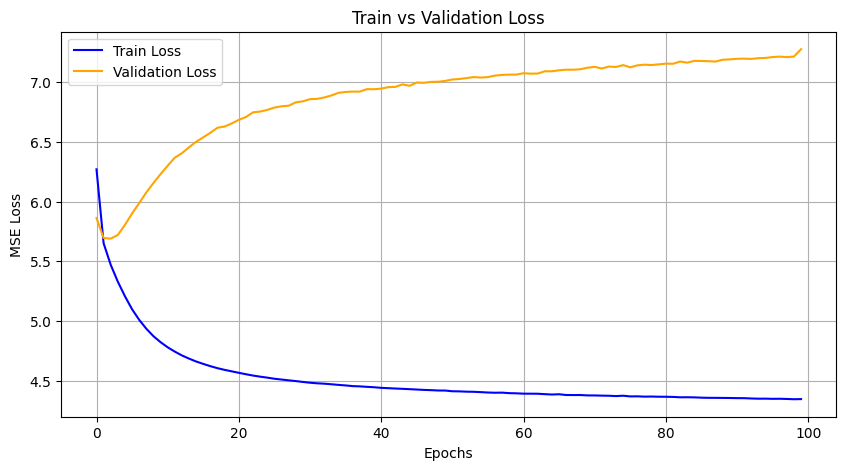

### **Hyperparameter 세팅**



*   Optimizer: Adam
*   Epoch: 100
*   Loss: MSE Loss



In [ ]:
#모델 초기화 및 Hyperparameter 세팅
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LightGCN(num_users, num_items).to(device) # 여기서 embedding 크기는 64로 했습니다. (젤 성능이 잘나옴)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

adj_matrix = get_adj_matrix(train_edge_index, num_users, num_items).to(device)
epochs = 100
loss_fn = nn.MSELoss()

train_loss_history = []
val_loss_history = []

Using device: cuda


### **Training / Validation**

**y hat = user_embedding * item_embedding**

평가 함수는 Dot-Product기반 implicit score prediction

In [ ]:
# Validation 평가 함수
def evaluate(model, edge_index, values):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(adj_matrix)
        users = edge_index[0].to(device)
        items = edge_index[1].to(device)
        targets = values.to(device)

        preds = (user_emb[users] * item_emb[items]).sum(dim=1)
        loss = loss_fn(preds, targets)
    return loss.item()

In [ ]:
#Training 루프
print("Start Training...")
best_val_loss = float('inf')

for epoch in tqdm(range(epochs)):
    # --- Training Step ---
    model.train()
    optimizer.zero_grad()

    user_emb, item_emb = model(adj_matrix)

    users = train_edge_index[0].to(device)
    items = train_edge_index[1].to(device)
    targets = train_values.to(device)

    preds = (user_emb[users] * item_emb[items]).sum(dim=1)

    loss = loss_fn(preds, targets)
    loss.backward()
    optimizer.step()

    train_loss = loss.item()
    train_loss_history.append(train_loss)

    # --- Validation Step ---
    val_loss = evaluate(model, val_edge_index, val_values)
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training Completed!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Start Training...


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.1088 | Val Loss: 1.1074
Epoch 2 | Train Loss: 1.3269 | Val Loss: 0.0792
Epoch 3 | Train Loss: 0.0777 | Val Loss: 0.0794
Epoch 4 | Train Loss: 0.0784 | Val Loss: 0.3307
Epoch 5 | Train Loss: 0.3917 | Val Loss: 0.6638
Epoch 6 | Train Loss: 0.7920 | Val Loss: 0.2831
Epoch 7 | Train Loss: 0.3358 | Val Loss: 0.0821
Epoch 8 | Train Loss: 0.0872 | Val Loss: 0.0840
Epoch 9 | Train Loss: 0.0822 | Val Loss: 0.0936
Epoch 10 | Train Loss: 0.0921 | Val Loss: 0.0820
Epoch 11 | Train Loss: 0.0826 | Val Loss: 0.0921
Epoch 12 | Train Loss: 0.1030 | Val Loss: 0.1538
Epoch 13 | Train Loss: 0.1852 | Val Loss: 0.1945
Epoch 14 | Train Loss: 0.2367 | Val Loss: 0.1546
Epoch 15 | Train Loss: 0.1856 | Val Loss: 0.0963
Epoch 16 | Train Loss: 0.1092 | Val Loss: 0.0740
Epoch 17 | Train Loss: 0.0760 | Val Loss: 0.0798
Epoch 18 | Train Loss: 0.0783 | Val Loss: 0.0911
Epoch 19 | Train Loss: 0.0893 | Val Loss: 0.0966
Epoch 20 | Train Loss: 0.0952 | Val Loss: 0.0943
Epoch 21 | Train Loss: 0.0931

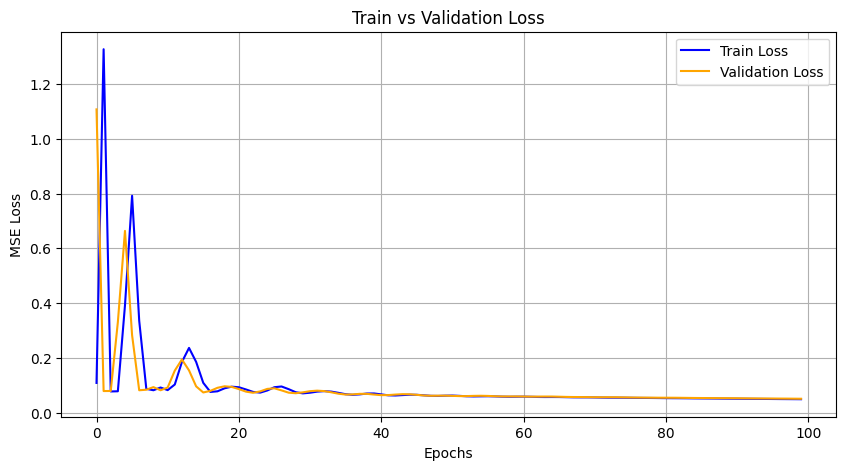

In [ ]:
#Loss 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Test Set 기반 최종 Loss
test_loss = evaluate(model, test_edge_index, test_values)
print(f"Final Test Loss (MSE): {test_loss:.4f}")

Final Test Loss (MSE): 0.0516


## **D. 개별 게임 추천**

###**게임 추천**

LightGCN에서 학습한
*   사용자 임베딩
*   게임 임베딩

을 사용하여 각 게임에 대한 내적 기반 점수 계산

= "유저의 취향 게임와 가장 비슷한 게임 추천"

추천 결과의 해석을 위해
1. 유저 플레이 히스토리 분석

### **번들 추천 함수**

추천 단계는 다음과 같음
1. 유저 존재 여부 확인
2. 플레이 기록(Top 5 게임) 분석
3. LightGCN 기반 점수 계산
4. 상위 K개 게임을 추천
5. 게임에 포함된 게임 요약 태그 출력

In [ ]:
def recommend_bundles(user_steam_id, top_k=3):
    model.eval()

    # 1. 유저 존재 여부 확인
    if user_steam_id not in user_id_map:
        print(f"User {user_steam_id} not found in training data.")
        return

    u_idx = user_id_map[user_steam_id]

    # 2. 유저의 과거 플레이 기록 분석 (History)
    # users_df는 전체 데이터이므로, 여기서 해당 유저의 기록을 조회
    user_history = users_df[users_df['steamid'] == user_steam_id].sort_values(by='playtime_forever', ascending=False)
    top_played_games = user_history.head(5)

    print(f"\n{'='*60}")
    print(f" 🎮 User Analysis: {user_steam_id}")
    print(f"{'='*60}")
    print("Top 5 Played Games (Past History):")
    if not top_played_games.empty:
        for _, row in top_played_games.iterrows():
            # 게임 이름 찾기
            g_name_series = games_df[games_df['appid'] == row['appid']]['name']
            g_name = g_name_series.values[0] if len(g_name_series) > 0 else "Unknown Game"

            # 게임 장르 찾기
            g_genre_series = games_df[games_df['appid'] == row['appid']]['genre']
            g_genre = g_genre_series.values[0] if len(g_genre_series) > 0 else "Unknown Genre"

            print(f" - {g_name} (Genre: {g_genre})")
    else:
        print(" - No play history found in dataset.")

    # 3. 모델을 이용한 추천 점수 계산 (Prediction)
    with torch.no_grad():
        user_emb, item_emb = model(adj_matrix)
        u_vector = user_emb[u_idx]

        # 모든 번들과의 내적(유사도) 계산
        scores = torch.matmul(item_emb, u_vector)

    # 상위 K개 번들 추출
    top_indices = torch.topk(scores, top_k).indices.cpu().numpy()

    # 4. 추천 결과 출력
    print(f"\n{'='*60}")
    print(f" ✨ AI Recommendations (Top {top_k} Bundles)")
    print(f"{'='*60}")

    for rank, bundle_idx in enumerate(top_indices):
        games_in_bundle = bundle_to_games.get(bundle_idx, [])
        score = scores[bundle_idx].item()

        # 번들 내 게임들의 주요 태그/장르 분석하여 키워드 뽑기
        all_tags = []
        for g_name in games_in_bundle:
            # 게임 이름으로 태그 데이터 검색
            tag_data = games_df[games_df['name'] == g_name]['tags'].values
            if len(tag_data) > 0:
                # 태그 문자열 처리 (예: "FPS, Action")
                all_tags.extend([t.strip() for t in str(tag_data[0]).split(',')])

        # 가장 흔한 태그 3개 추출
        if all_tags:
            common_tags = [tag for tag, count in Counter(all_tags).most_common(5)]
            tags_str = ", ".join(common_tags)
        else:
            tags_str = "No Tags"

        print(f"\n[Rank {rank+1}] Bundle Score: {score:.4f}")
        print(f"Key Themes: {tags_str} ...")
        print(f"Games included ({len(games_in_bundle)} games):")

        # 번들 안의 게임 목록 (최대 5개 표시)
        for g in games_in_bundle[:5]:
            print(f"  └─ {g}")

        if len(games_in_bundle) > 5:
            print(f"     ... and {len(games_in_bundle)-5} more games")

In [ ]:
# --- 테스트 실행 ---
# 데이터셋에 있는 첫 번째 유저 아이디를 가져와서 테스트
if len(unique_users) > 0:
    test_target_user = unique_users[0]
    recommend_bundles(test_target_user)
else:
    print("No users found.")


 🎮 User Analysis: '76561198828387620
Top 5 Played Games (Past History):
 - Metaphor: ReFantazio (Genre: Action, Adventure, RPG)
 - Dragon's Dogma 2 (Genre: Action, RPG)
 - ELDEN RING (Genre: Action, RPG)
 - Cube Racer (Genre: Action, Casual, Indie, Racing)
 - Monster Hunter: World (Genre: Action)

 ✨ AI Recommendations (Top 3 Bundles)

[Rank 1] Bundle Score: 0.4452
Key Themes: No Tags ...
Games included (1 games):
  └─ 730

[Rank 2] Bundle Score: 0.3254
Key Themes: No Tags ...
Games included (1 games):
  └─ 570

[Rank 3] Bundle Score: 0.3152
Key Themes: No Tags ...
Games included (1 games):
  └─ 578080


###**추천 성능 Evalutation**

**1. Ground Truth (정답 집합)**

테스트 데이터에서 유저가 실제로 상호작용한 개별 아이템(게임)들의 집합이다.
모델이 맞춰야 하는 "정답(label)" 역할을 한다.

T_u = { test 데이터에서 등장한 item_id 들 }


**2. Model Prediction (Top-K 추천 결과)**

LightGCN 또는 LLM ranking이 예측한 상위 K개의 아이템 목록이다.
유저에게 “이 K개 중에서 어떤 걸 할 것 같아?”라고 추천하는 셈이다.

P_u(k) = { Top-K recommended item_id }


**3. Precision@K**

추천된 K개 중에서 실제 정답이 얼마나 포함되었는지 비율로 나타낸다.
추천 리스트의 “정확도(precision)” 개념과 동일하다.

K = 5일 때
정답 3개 맞추면 Precision@5 = 0.6
정답 1개면 Precision@5 = 0.2

공식:
Precision@K = | T_u ∩ P_u(k) | / K

특징:
- 추천을 많이 해도 정확히 뽑는지 평가
- K가 커질수록 Precision은 보통 떨어짐


**4. Recall@K**

정답 중에서 모델이 얼마나 맞췄는지 비율로 평가한다.

예시:
유저가 실제로 4개의 item을 했는데
모델이 2개를 맞췄다면 Recall@K = 0.5

공식:
Recall@K = | T_u ∩ P_u(k) | / | T_u |


**5. Hit Rate@K**

Top-K 추천 안에 정답이 하나라도 포함되어 있으면 Hit = 1, 아니면 0.

공식:
Hit@K = 1   if | T_u ∩ P_u(k) | > 0
Hit@K = 0   otherwise


**6. NDCG@K (Normalized Discounted Cumulative Gain)**

순위를 고려하는 추천 품질 지표.
정답을 상위에 배치할수록 더 높은 점수가 주어진다.

**6-1. DCG@K**

DCG@K = Σ ( rel_i / log2(i + 1) )
rel_i = 1 (정답이면)
rel_i = 0 (오답이면)

**6-2. IDCG@K**

해당 유저의 정답을 가장 이상적으로 위에서부터 모두 배치했을 때의 DCG

IDCG@K = Σ ( 1 / log2(i + 1) ), i = 1 ... min(|T_u|, K)

**6-3. NDCG@K**
NDCG@K = DCG@K / IDCG@K


In [ ]:
import math

def ndcg_at_k(recommended_items, true_items, k):
    """
    recommended_items: 예측 item 리스트 (순서 있음, 길이는 k 이상이어도 됨)
    true_items: 정답 item 집합 (set 권장)
    k: 상위 몇 개까지 볼지 (3, 5, 10 등)
    """
    # DCG 계산
    dcg = 0.0
    for rank, item in enumerate(recommended_items[:k]):
        if item in true_items:
            dcg += 1.0 / math.log2(rank + 2)  # rank는 0부터 시작이라 +2

    # IDCG 계산 (정답을 이상적으로 위에서부터 다 맞춘 경우)
    ideal_hits = min(len(true_items), k)
    if ideal_hits == 0:
        return 0.0

    idcg = 0.0
    for rank in range(ideal_hits):
        idcg += 1.0 / math.log2(rank + 2)

    return dcg / idcg if idcg > 0 else 0.0




In [ ]:
import numpy as np
from tqdm.notebook import tqdm

def evaluate_average_performance(model, test_df, k_list=[3, 5, 10]):
    """
    전체 Test 유저에 대해 추천 성능 지표
    (Precision, Recall, Hit Rate, NDCG)의 평균을 계산합니다.
    """
    model.eval()

    # 평가 대상 유저 (Test Set에 있는 유저들)
    test_users = test_df['user_idx'].unique()
    print(f"Calculating average metrics for {len(test_users)} users...")

    # 결과 저장 딕셔너리
    metrics = {
        k: {
            'precision': [],
            'recall': [],
            'hit_rate': [],
            'ndcg': []
        } for k in k_list
    }

    max_k = max(k_list)

    with torch.no_grad():
        # 전체 임베딩 계산 (한 번만 수행)
        user_emb, item_emb = model(adj_matrix)

        # 배치 단위 처리
        batch_size = 1024
        for i in tqdm(range(0, len(test_users), batch_size)):
            batch_users = test_users[i : i + batch_size]

            # 배치 유저 임베딩
            u_vectors = user_emb[batch_users]  # (batch_size, emb_dim)

            # 점수 계산 (Batch Users x All Items)
            scores = torch.matmul(u_vectors, item_emb.t())

            for idx, u_idx in enumerate(batch_users):
                # 정답셋 (Ground Truth)
                true_bundles = set(test_df[test_df['user_idx'] == u_idx]['bundle_id'].values)
                if len(true_bundles) == 0:
                    continue

                user_scores = scores[idx]

                # 한 번만 Top-max_k 뽑고, k별로 prefix 사용
                top_indices = torch.topk(user_scores, max_k).indices.cpu().numpy()

                for k in k_list:
                    top_k_indices = top_indices[:k]
                    pred_bundles = set(top_k_indices)

                    # 맞춘 개수
                    hit_count = len(true_bundles & pred_bundles)

                    # Precision / Recall / Hit Rate
                    metrics[k]['precision'].append(hit_count / k)
                    metrics[k]['recall'].append(hit_count / len(true_bundles))
                    metrics[k]['hit_rate'].append(1 if hit_count > 0 else 0)

                    # NDCG (순위 정보 사용)
                    metrics[k]['ndcg'].append(
                        ndcg_at_k(top_indices, true_bundles, k)
                    )

    # 결과 출력
    print(f"\n{'='*50}")
    print(" 📊 Average Performance Across All Test Users")
    print(f"{'='*50}")

    for k in k_list:
        avg_p = np.mean(metrics[k]['precision'])
        avg_r = np.mean(metrics[k]['recall'])
        avg_h = np.mean(metrics[k]['hit_rate'])
        avg_n = np.mean(metrics[k]['ndcg'])

        print(
            f"[Top-{k}] Precision: {avg_p:.4f} | "
            f"Recall: {avg_r:.4f} | "
            f"Hit Rate: {avg_h:.4f} | "
            f"NDCG: {avg_n:.4f}"
        )

# 실행
evaluate_average_performance(model, test_df)

Calculating average metrics for 17358 users...


  0%|          | 0/17 [00:00<?, ?it/s]


 📊 Average Performance Across All Test Users
[Top-3] Precision: 0.0883 | Recall: 0.1106 | Hit Rate: 0.2461 | NDCG: 0.1206
[Top-5] Precision: 0.0718 | Recall: 0.1370 | Hit Rate: 0.3186 | NDCG: 0.1266
[Top-10] Precision: 0.0547 | Recall: 0.1856 | Hit Rate: 0.4412 | NDCG: 0.1429


## **F.Negative Sampling 활용 모델 파인튜닝**

###**BPR(Baysian Personalized Ranking)**

이 단계에서는 MSE 대신 BPR기반 학습을 사용해서 Negative Sampling의 효과를 탐색한다.

이 과정은 다음의 네 단계로 구성된다.
1. (A) Negative Sampling: 유저가 하지 않은 번들 샘플링  
2. (B) BPR Loss 정의: (u, i, j) 삼중쌍에 대한 pairwise ranking 손실  
3. (C) BPR Fine-tuning: 기존 모델을 BPR로 미세조정  
4. (D) Test Evaluation: Test 세트 기준 성능 측정

### **Negative Sampling**
Negative Sampling에서는, 유저가 플레이 기록이 없는 게임만을 포함하는 번들을 무작위로 샘플링한다.

처음에는 모델에서 Similarity가 낮은 번들을 선택했으나, 성능이 감소하였다. 이는 오히려 similarity가 낮다고 유저가 플레이하지 않을 것이라고(negative sample이라고 확정) 간주하는 것이 틀린 접근임을 보여준다.

In [ ]:
#실제 플레이한 번들

user_pos_bundles = defaultdict(set)
for u, b in zip(train_df['user_idx'].values, train_df['bundle_id'].values):
    user_pos_bundles[u].add(b)

all_bundles = np.arange(num_items)

model.eval()
with torch.no_grad():
    user_emb, item_emb = model(adj_matrix)

neg_pairs = []

#Negative Sample 크기

n_neg_per_user = 1

#상호작용하지 않은 번들을 무작위로 샘플
for u in tqdm(range(num_users)):
    pos = np.array(list(user_pos_bundles[u]))
    if len(pos) == 0:
        continue

    scores = torch.matmul(user_emb[u], item_emb.t()).cpu().numpy()

    #이미 플레이한 번들
    scores[pos] = -np.inf


    candidates = np.setdiff1d(np.arange(num_bundles), pos)  # 아직 안 한 번들들
    if len(candidates) < n_neg_per_user:
        neg_idx = candidates
    else:
        neg_idx = np.random.choice(candidates, size=n_neg_per_user, replace=False)


    for j in neg_idx:
        neg_pairs.append((u, int(j)))

neg_df = pd.DataFrame(neg_pairs, columns=['user_idx', 'bundle_id'])

  0%|          | 0/22472 [00:00<?, ?it/s]

### **BPR Loss**

유저에 대해 실제로 플레이한 번들의 점수가 플레이하지 않은 번들의 점수보다 높아지도록 학습

In [ ]:
#BPR Loss 정의

def bpr_loss(user_emb, item_emb, users, pos_items, neg_items, lambda_reg=1e-4):

    u_e = user_emb[users]
    i_e = item_emb[pos_items]
    j_e = item_emb[neg_items]   # (B, d)

    pos_scores = (u_e * i_e).sum(dim=1)
    neg_scores = (u_e * j_e).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

    reg = (u_e.norm(2, dim=1).pow(2) +
           i_e.norm(2, dim=1).pow(2) +
           j_e.norm(2, dim=1).pow(2)).mean()

    return loss + lambda_reg * reg

In [ ]:
#user별 negative
user_neg_list = defaultdict(list)
for u, b in zip(neg_df['user_idx'].values, neg_df['bundle_id'].values):
    user_neg_list[u].append(b)

train_u = train_df['user_idx'].values
train_i = train_df['bundle_id'].values
train_j = []

rng = np.random.default_rng(42)

#Negative sample 존재 안할 시, 양성에 없는 번들 중 랜덤으로 샘플링
#Negative Sample 존재 시 해당 negative sample 중 하나 선택

for u in train_u:
    negs = user_neg_list[u]
    if len(negs) == 0:
        while True:
            j = rng.integers(low=0, high=num_items)
            if j not in user_pos_bundles[u]:
                train_j.append(int(j))
                break
    else:
        j = rng.choice(negs)
        train_j.append(int(j))

train_u_tensor = torch.tensor(train_u, dtype=torch.long, device=device)
train_i_tensor = torch.tensor(train_i, dtype=torch.long, device=device)
train_j_tensor = torch.tensor(train_j, dtype=torch.long, device=device)

print("BPR용 triple tensor 준비 완료:")
print("  users :", train_u_tensor.shape)
print("  pos   :", train_i_tensor.shape)
print("  neg   :", train_j_tensor.shape)

BPR용 triple tensor 준비 완료:
  users : torch.Size([847778])
  pos   : torch.Size([847778])
  neg   : torch.Size([847778])


### **BPR Fine-tuning**

Train에서 관측된 (u, i)에 대해 (u, i, j-negative sample)을 만듦.

그 다음, BPR epoch마다:

1. `(u, i, j)` triple들을 섞어서(mini-batch SGD)
2. `model(adj_matrix)` 로 현재 user/item 임베딩을 다시 계산하고
3. `bpr_loss(user_emb, item_emb, u_batch, i_batch, j_batch)` 를 구해
4. `loss.backward()` 와 `optimizer.step()` 으로 파라미터 업데이트

이 과정을 통해 모델은:

- 이 유저는 i 번들을 선호하고, j 번들은 덜 선호한다”는 방향으로  
  랭킹 구조를 점점 더 정교하게 학습하게 된다

In [ ]:
#BPR 파인튜닝 실
bpr_epochs = 5
batch_size = 4096

print("\n[Stage 2] BPR Fine-tuning 시작...")

for epoch in range(bpr_epochs):
    model.train()
    permutation = torch.randperm(train_u_tensor.size(0), device=device)
    epoch_loss = 0.0
    total_examples = 0

    for start in range(0, train_u_tensor.size(0), batch_size):
        idx = permutation[start:start+batch_size]
        u_batch = train_u_tensor[idx]
        i_batch = train_i_tensor[idx]
        j_batch = train_j_tensor[idx]

        optimizer.zero_grad()

        user_emb, item_emb = model(adj_matrix)

        loss = bpr_loss(user_emb, item_emb, u_batch, i_batch, j_batch)
        loss.backward()
        optimizer.step()

        batch_size_actual = u_batch.size(0)
        epoch_loss += loss.item() * batch_size_actual
        total_examples += batch_size_actual

    avg_loss = epoch_loss / total_examples
    print(f"[BPR Epoch {epoch+1}/{bpr_epochs}] Loss: {avg_loss:.4f}")


[Stage 2] BPR Fine-tuning 시작...
[BPR Epoch 1/5] Loss: 0.1112
[BPR Epoch 2/5] Loss: 0.0474
[BPR Epoch 3/5] Loss: 0.0316
[BPR Epoch 4/5] Loss: 0.0233
[BPR Epoch 5/5] Loss: 0.0185


In [ ]:
evaluate_average_performance(model, test_df)

Calculating average metrics for 17358 users...


  0%|          | 0/17 [00:00<?, ?it/s]


 📊 Average Performance Across All Test Users
[Top-3] Precision: 0.0959 | Recall: 0.1181 | Hit Rate: 0.2658 | NDCG: 0.1304
[Top-5] Precision: 0.0775 | Recall: 0.1442 | Hit Rate: 0.3411 | NDCG: 0.1360
[Top-10] Precision: 0.0594 | Recall: 0.2006 | Hit Rate: 0.4729 | NDCG: 0.1539
